In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


/petrogeo/home/emmanuel/Área de trabalho/diffseis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from src.diffusion import Dataset
from torch.utils.data import DataLoader

folder = 'data/'
image_size = (64, 128)
mode = 'demultiple'

dataset = Dataset(folder, image_size, mode)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, pin_memory=True)

In [ ]:
from src.unet import UNet
import torch.nn.functional as F
from torch.optim import Adam

model = UNet(in_channel=1, out_channel=1).to(device)
optimizer = Adam(model.parameters(), lr=2e-5)
loss_fn = F.mse_loss

In [ ]:
epochs = 150
model.train()

loss_history = []
pbar = tqdm(range(epochs))

for epoch in pbar:
    epoch_loss = 0.0
    for batch in dataloader:
        inputs, gt = batch
        inputs = inputs.to(device)
        gt = gt.to(device)
        
        # Lógica do modelo de difusão: a rede aprende a prever o ruído inserido
        noise_target = inputs - gt
        time = torch.zeros(inputs.size(0), device=device)
        
        optimizer.zero_grad()
        preds = model(inputs, time)
        loss = loss_fn(preds, noise_target)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
        
    # Salva a média da loss da época (ou pode salvar por iteração, como preferir)
    loss_history.append(epoch_loss / len(dataloader))

# --- Plotagem da Curva de Loss ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_history, color='blue', linewidth=2)
ax.set_title('Convergência do Treinamento - MSE Loss', fontsize=14, pad=15)
ax.set_xlabel('Épocas', fontsize=12)
ax.set_ylabel('Erro (MSE)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('results/loss_curve_final.png', dpi=300, facecolor='white')
plt.show()


  6%|▋         | 129/2000 [09:54<2:23:40,  4.61s/it, loss=0.000351]


KeyboardInterrupt: 

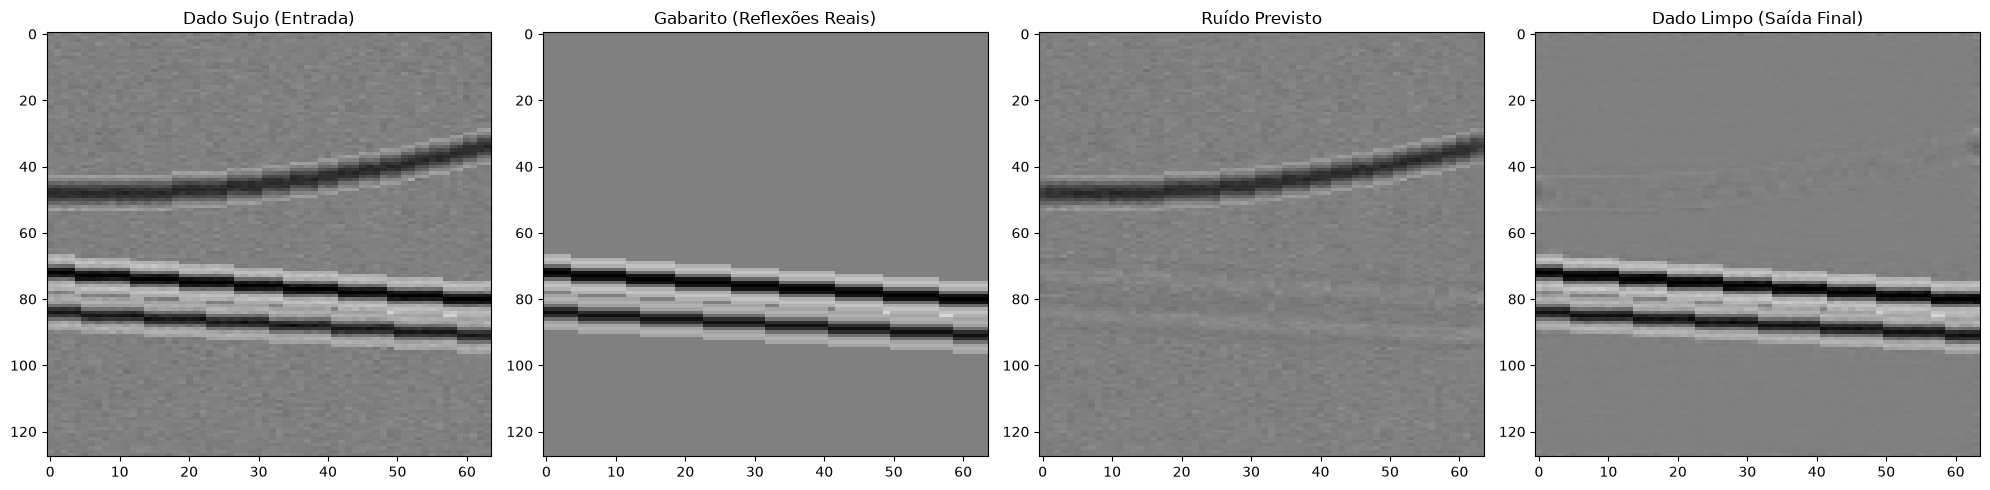

In [ ]:
model.eval()
with torch.no_grad():
    batch = next(iter(dataloader))
    inputs, gt = batch
    inputs = inputs.to(device)
    gt = gt.to(device)
    
    time = torch.zeros(inputs.size(0), device=device)
    predicted_noise = model(inputs, time)
    dado_limpo = inputs - predicted_noise
    
    dado_sujo_np = inputs[0, 0].cpu().numpy()
    gabarito_np = gt[0, 0].cpu().numpy()
    ruido_np = predicted_noise[0, 0].cpu().numpy()
    dado_limpo_np = dado_limpo[0, 0].cpu().numpy()
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    vmax = max(np.max(np.abs(dado_sujo_np)), np.max(np.abs(gabarito_np)))
    
    axes[0].imshow(dado_sujo_np.T, cmap='gray', aspect='auto', vmin=-vmax, vmax=vmax)
    axes[0].set_title('Dado Sujo (Entrada)')
    
    axes[1].imshow(gabarito_np.T, cmap='gray', aspect='auto', vmin=-vmax, vmax=vmax)
    axes[1].set_title('Gabarito (Reflexões Reais)')
    
    axes[2].imshow(ruido_np.T, cmap='gray', aspect='auto', vmin=-vmax, vmax=vmax)
    axes[2].set_title('Ruído Previsto')
    
    axes[3].imshow(dado_limpo_np.T, cmap='gray', aspect='auto', vmin=-vmax, vmax=vmax)
    axes[3].set_title('Dado Limpo (Saída Final)')
    
    plt.tight_layout()
    plt.show()